# EDA — Báo Chính phủ

Phân tích `bao_chinh_phu.json`: chuyên mục, độ phủ ngày xuất bản, chất lượng dữ liệu, độ dài nội dung và mẫu bài.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "bao_chinh_phu"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 2,500 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output_news\bao_chinh_phu.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output_news\bao_chinh_phu.json`  
**Kích thước:** 21.22 MB

,Chỉ số,Giá trị
0,Số bài,"2,500"
1,Số domain nguyên bản,6
2,Số domain sau khi tách,6
3,Bài đa-domain,0
4,Ngày hợp lệ,"2,450 (98.0%)"
5,Ngày nhỏ nhất,2026-01-16
6,Ngày lớn nhất,2026-07-23
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,dc1f4b1ff4f301b43fe9a919cc5d77e9,Báo Chính phủ,Chính trị,2026-07-23,Thông cáo báo chí ngày làm việc thứ tư Hội nghị Trung ương 3 khoá XIV,TRUE,https://baochinhphu.vn/thong-cao-bao-chi-ngay-lam-viec-thu-tu-hoi-nghi-trung-uong-3-khoa-xiv-102...
1,a8baa489acb1ece1ad62529d5d1c2aa2,Báo Chính phủ,Chính trị,2026-07-23,"Áp thấp nhiệt đới mạnh lên thành bão trong 24 giờ tới, đi vào Biển Đông",TRUE,https://baochinhphu.vn/ap-thap-nhiet-doi-manh-len-thanh-bao-trong-24-gio-toi-di-vao-bien-dong-10...
2,8598ab8535d40c51e36233413cc84a81,Báo Chính phủ,Chính trị,2026-07-23,"Hội nghị công bố các quyết định của Bộ Chính trị, Ban Bí thư về công tác cán bộ",TRUE,https://baochinhphu.vn/hoi-nghi-cong-bo-cac-quyet-dinh-cua-bo-chinh-tri-ban-bi-thu-ve-cong-tac-c...
3,2c7b2d2e345de8403f99d578b1ee4a2c,Báo Chính phủ,Chính trị,2026-07-23,"Thủ tướng Chính phủ phát động ""Phong trào đẩy mạnh chăm lo người có công với cách mạng""",TRUE,https://baochinhphu.vn/thu-tuong-chinh-phu-phat-dong-phong-trao-day-manh-cham-lo-nguoi-co-cong-v...
4,21183541eee047aeb25b1abfd6a0d06f,Báo Chính phủ,Chính trị,2026-07-23,Thủ tướng Lê Minh Hưng: Sự hy sinh của các thế hệ cha anh sẽ mãi mãi được khắc ghi trong lòng dâ...,TRUE,https://baochinhphu.vn/thu-tuong-le-minh-hung-su-hy-sinh-cua-cac-the-he-cha-anh-se-mai-mai-duoc-...


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,Kinh tế,447,0.18
1,Văn hóa,434,0.17
2,Xã hội,413,0.17
3,Quốc tế,407,0.16
4,Khoa giáo,404,0.16
5,Chính trị,395,0.16


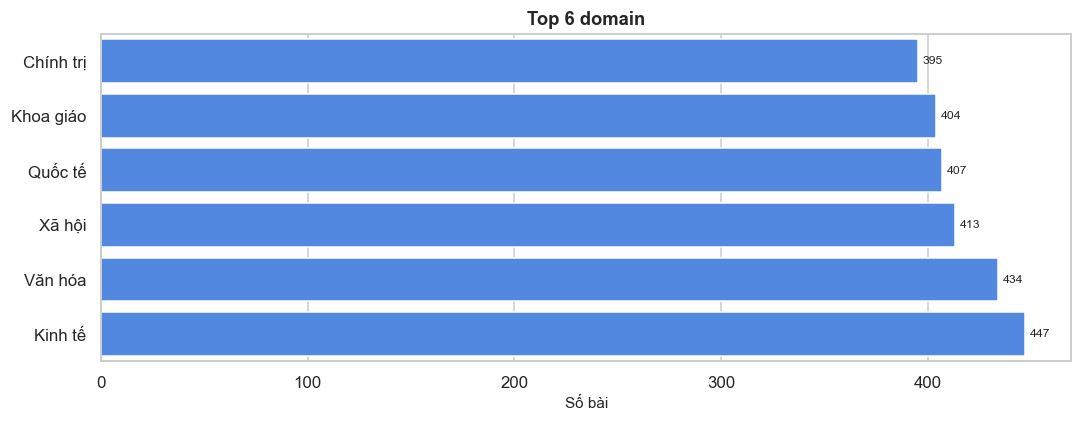

In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,2450,0.98
1,Thiếu/không parse được,50,0.02


,year,số_bài
0,2026,2450


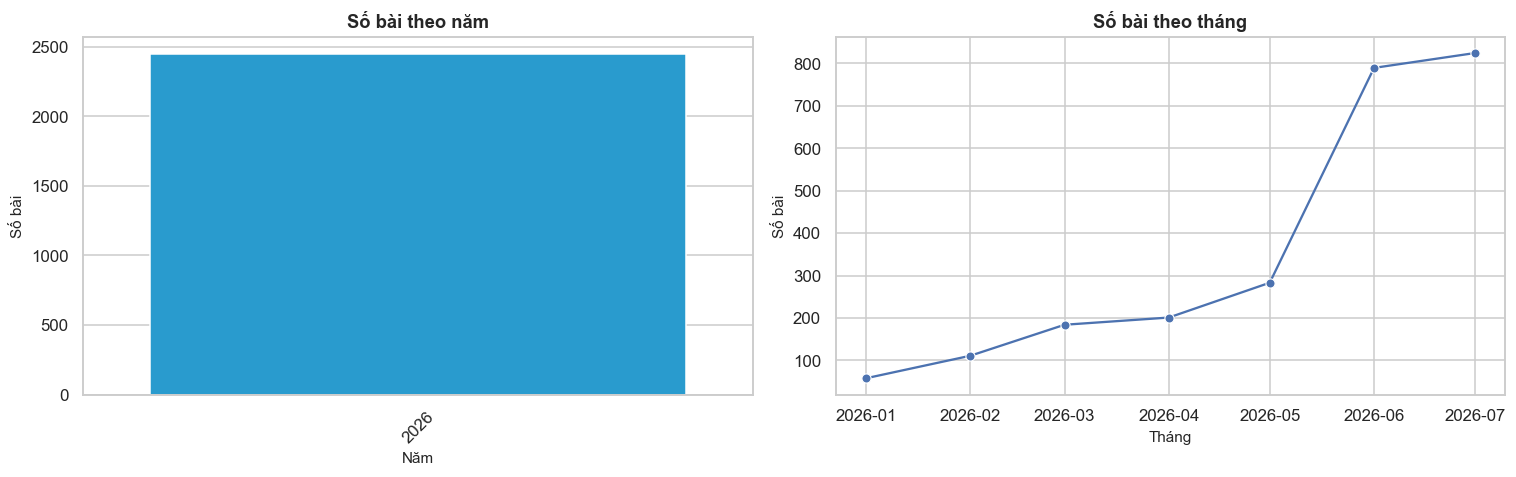

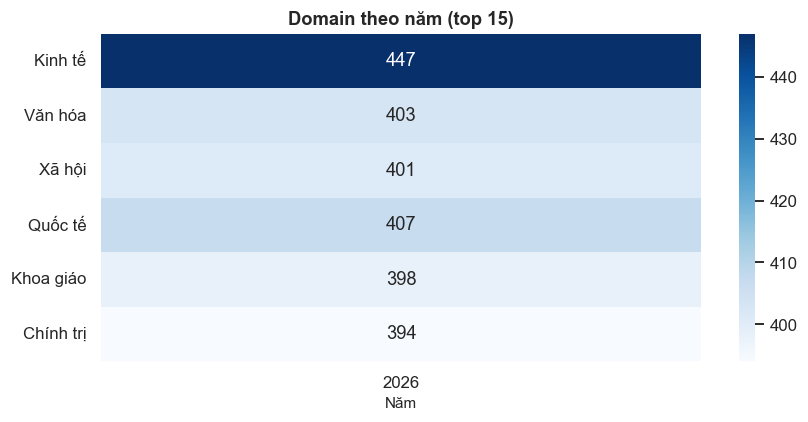

In [4]:
source_timeline(df, atomic_domains)

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,2500,100.00
1,publish_date,50,2.00
2,original_text,1,0.04
3,claim,0,0.00
4,domain,0,0.00
5,evidence,0,0.00
6,id,0,0.00
7,justification,0,0.00
8,label,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,2500
1,url,0,2500
2,claim,2,2498
3,original_text,8,2491


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,2500
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


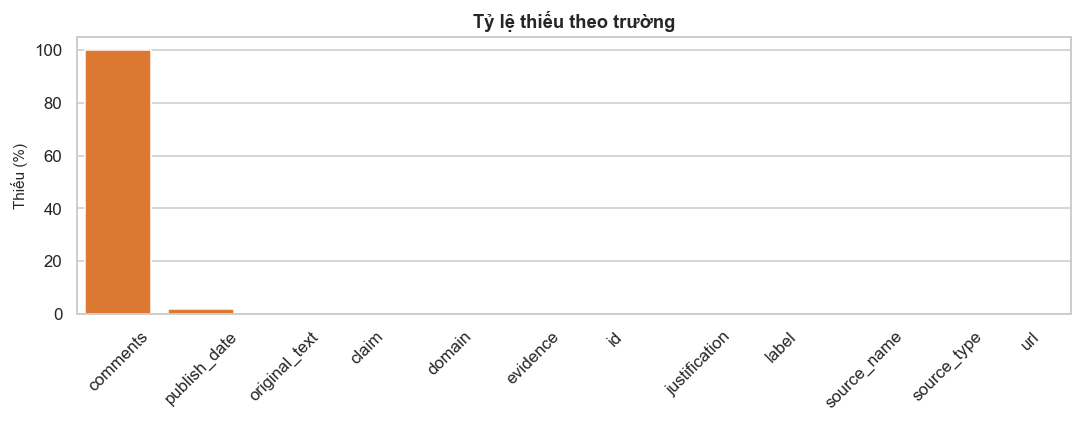

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,"2,500.00",16.59,4.33,3.00,14.00,16.00,19.00,22.00,24.00,29.00,42.00
original_text_words,"2,500.00",45.84,16.40,0.00,36.00,45.00,52.00,68.00,78.00,94.01,122.00
evidence_words,"2,500.00",10.00,0.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
justification_words,"2,500.00","1,293.47","1,058.98",36.00,806.00,"1,100.00","1,504.00","2,112.10","2,645.20","3,850.65","22,766.00"


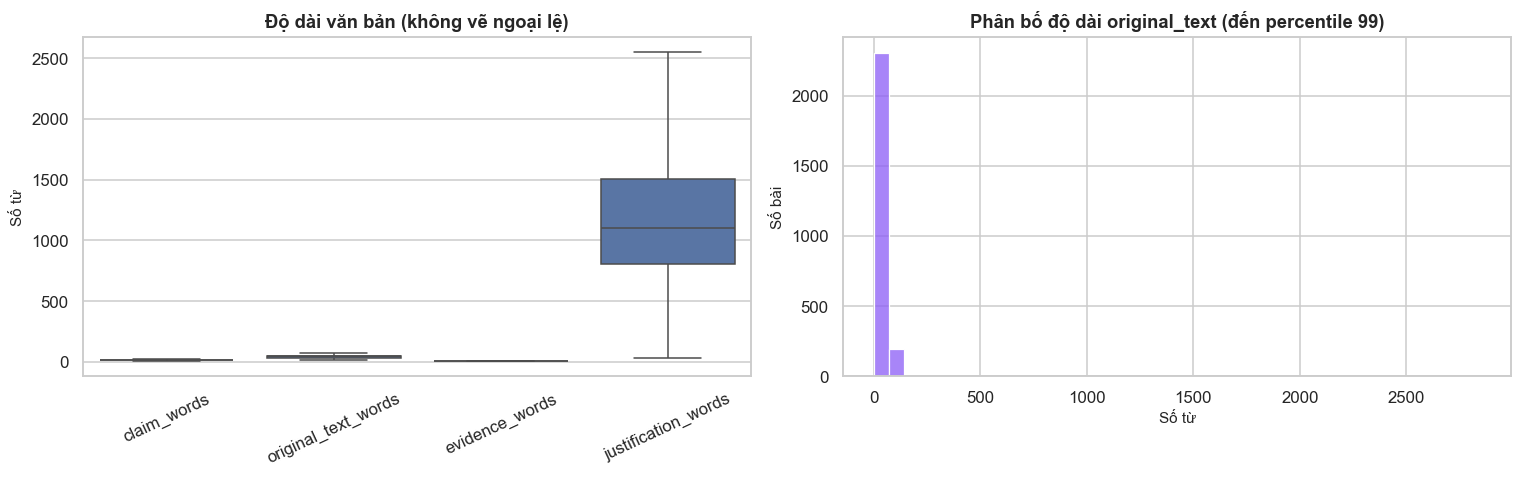

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Quốc tế,407,48.00,49.03,74.00
Chính trị,395,46.00,49.68,74.60
Khoa giáo,404,46.00,46.98,68.00
Xã hội,413,44.00,44.86,65.00
Kinh tế,447,43.00,43.77,58.00
Văn hóa,434,43.00,41.36,54.70


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,TRUE,2500,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,2500,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,Báo Chính phủ,2500,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,baochinhphu.vn,2431,0.97
1,thanglong.chinhphu.vn,50,0.02
2,tphcm.chinhphu.vn,10,0.00
3,media.chinhphu.vn,9,0.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Chính trị,2026-05-28,"Tổng Bí thư, Chủ tịch nước Tô Lâm và Phu nhân hội kiến Nhà Vua Thái Lan và Hoàng hậu",TRUE,https://baochinhphu.vn/tong-bi-thu-chu-tich-nuoc-to-lam-va-phu-nhan-hoi-kien-nha-vua-thai-lan-va...
1,Chính trị,2026-05-29,Chủ tịch Quốc hội: Khẩn trương hoàn thiện dự thảo Luật Đô thị đặc biệt,TRUE,https://baochinhphu.vn/chu-tich-quoc-hoi-khan-truong-hoan-thien-du-thao-luat-do-thi-dac-biet-102...
2,Khoa giáo,2026-03-12,Quy đổi chứng chỉ ngoại ngữ trong tuyển sinh 2026: Thí sinh cần lưu ý gì?,TRUE,https://baochinhphu.vn/quy-doi-chung-chi-ngoai-ngu-trong-tuyen-sinh-2026-thi-sinh-can-luu-y-gi-1...
3,Khoa giáo,2026-03-12,Đưa kinh tế không gian tầm thấp bảo vệ biển đảo và thềm lục địa,TRUE,https://baochinhphu.vn/kinh-te-khong-gian-tam-thap-bao-ve-bien-dao-va-them-luc-dia-1022603121015...
4,Kinh tế,2026-06-09,Phó Thủ tướng Thường trực Phạm Gia Túc làm việc với Hội đồng Năng lượng gió toàn cầu,TRUE,https://baochinhphu.vn/pho-thu-tuong-thuong-truc-pham-gia-tuc-lam-viec-voi-hoi-dong-nang-luong-g...
5,Kinh tế,2026-06-11,Thị trường chứng khoán cần tận dụng cơ hội thu hút dòng vốn lớn,TRUE,https://baochinhphu.vn/thi-truong-chung-khoan-can-tan-dung-co-hoi-thu-hut-dong-von-lon-102260611...
6,Quốc tế,2026-01-29,WHO: Khả năng lây lan bệnh do virus Nipah tại Việt Nam ở mức thấp,TRUE,https://baochinhphu.vn/kha-nang-lay-lan-benh-do-virus-nipah-tai-viet-nam-o-muc-thap-who-10226012...
7,Quốc tế,2026-01-29,Việt Nam nêu quan điểm về căng thẳng Mỹ-Iran,TRUE,https://baochinhphu.vn/viet-nam-neu-quan-diem-ve-cang-thang-my-iran-102260129172324632.htm
8,Văn hóa,2026-01-16,Đưa điện ảnh Việt Nam đến gần hơn với điện ảnh thế giới,TRUE,https://baochinhphu.vn/dua-dien-anh-viet-nam-den-gan-hon-voi-dien-anh-the-gioi-10226011623513962...
9,Văn hóa,2026-01-17,"Chiến thắng nghẹt thở trước U23 UAE, U23 Việt Nam tiến vào bán kết",TRUE,https://baochinhphu.vn/lich-thi-dau-tran-tu-ket-u23-viet-nam-u23-uae-102260114074424516.htm


### Nhận xét tự động
- Có **2,500** bài và **6** domain sau khi tách.
- Domain lớn nhất là **Kinh tế** với **447** lượt gán.
- Có **0** bài đa-domain và **50** bài thiếu/không parse được ngày.
- Phân bố nhãn: **TRUE: 2,500**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.